## Benchmarking Machine Learning Approaches for Energy Prediction

### Objective
This project systematically benchmarks different machine learning modelling approaches for predicting household energy consumption.

### 01_EDA
This notebook focuses on:
- Understanding the dataset
- Exploring feature distributions
- Identifying data quality issues

**Imports**

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

**Load the dataset**

In [2]:
# Load datasets
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
synthetic_df = pd.read_csv("../data/synthetic_data.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Synthetic shape:", synthetic_df.shape)

Train shape: (90000, 7)
Test shape: (390, 5)
Synthetic shape: (390, 5)


In [3]:
print("Training Data columns: \n",train_df.columns.to_list())
print("Test Data columns: \n",test_df.columns.to_list())
print("Synthetic Data columns: \n",synthetic_df.columns.to_list())


Training Data columns: 
 ['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh']
Test Data columns: 
 ['Household_ID', 'Date', 'County', 'Has_AC', 'Avg_Temperature_C']
Synthetic Data columns: 
 ['Household_ID', 'Date', 'County', 'Energy_Consumption_kWh', 'Has_AC']


### **Data Preparation Pipeline (Train & Test)**

**1. Define Columns and setup**

In [5]:
target_col = "Energy_Consumption_kWh"
id_col = "Household_ID"
date_col = "Date"

**2. Convert Date and Extract Features**

In [6]:
def process_date(df):
    df[date_col] = pd.to_datetime(df[date_col])
    df["month"] = df[date_col].dt.month
    df["day_of_week"] = df[date_col].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    return df

train_df = process_date(train_df)
test_df = process_date(test_df)

C:\Users\khush\AppData\Local\Temp\ipykernel_29648\3050615551.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col])


**3. Cyclical Time Features**

In [7]:
# Cyclical Time Features
def add_time_features(df):
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    
    return df

train_df = add_time_features(train_df)
test_df = add_time_features(test_df)

In [8]:
drop_cols = ["month", "day_of_week"]

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

In [9]:
# As per assumption: test households = size 1
test_df["Household_Size"] = 1

**4. Interaction and non-linear features**

In [ ]:

train_df["temp_ac"] = train_df["Avg_Temperature_C"] * (train_df["Has_AC"] == "Yes").astype(int)
test_df["temp_ac"] = test_df["Avg_Temperature_C"] * (test_df["Has_AC"] == "Yes").astype(int)

# Non-linear temperature
train_df["temp_squared"] = train_df["Avg_Temperature_C"] ** 2
test_df["temp_squared"] = test_df["Avg_Temperature_C"] ** 2

# Per household effect
train_df["temp_per_person"] = train_df["Avg_Temperature_C"] / (train_df["Household_Size"] + 1)
test_df["temp_per_person"] = test_df["Avg_Temperature_C"] / (test_df["Household_Size"] + 1)

**5. Adding and removing columns**

In [11]:
# Drop 'County' from test since it is not available in train
test_df = test_df.drop(columns=["County"])

In [12]:
train_df.columns

Index(['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size',
       'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh', 'is_weekend',
       'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'temp_ac',
       'temp_squared', 'temp_per_person'],
      dtype='str')

In [13]:
test_df.columns

Index(['Household_ID', 'Date', 'Has_AC', 'Avg_Temperature_C', 'is_weekend',
       'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'Household_Size',
       'temp_ac', 'temp_squared', 'temp_per_person'],
      dtype='str')

In [14]:
features = ['Household_Size',
            'Avg_Temperature_C',
            'Has_AC',
            'is_weekend',
            'month_sin', 
            'month_cos', 
            'dow_sin', 
            'dow_cos', 
            'temp_ac',
            'temp_squared', 
            'temp_per_person'
        ]

#### 4. Train and Test Matrices

In [15]:
final_train_df = train_df[features + [target_col]].copy()
final_test_df = test_df[features].copy()

print("Final Train Shape:", final_train_df.shape)
print("Final Test Shape:", final_test_df.shape)

print("\nTrain Columns:", final_train_df.columns.tolist())
print("Test Columns:", final_test_df.columns.tolist())

Final Train Shape: (90000, 12)
Final Test Shape: (390, 11)

Train Columns: ['Household_Size', 'Avg_Temperature_C', 'Has_AC', 'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'temp_ac', 'temp_squared', 'temp_per_person', 'Energy_Consumption_kWh']
Test Columns: ['Household_Size', 'Avg_Temperature_C', 'Has_AC', 'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'temp_ac', 'temp_squared', 'temp_per_person']


In [16]:
final_train_df.to_csv("../data/interim/final_train_prepped.csv", index=False)
final_test_df.to_csv("../data/interim/final_test_prepped.csv", index=False)

### **Exploratory Data Analysis**

**1. Target variable Distribution (Energy Consumption (kWh))**

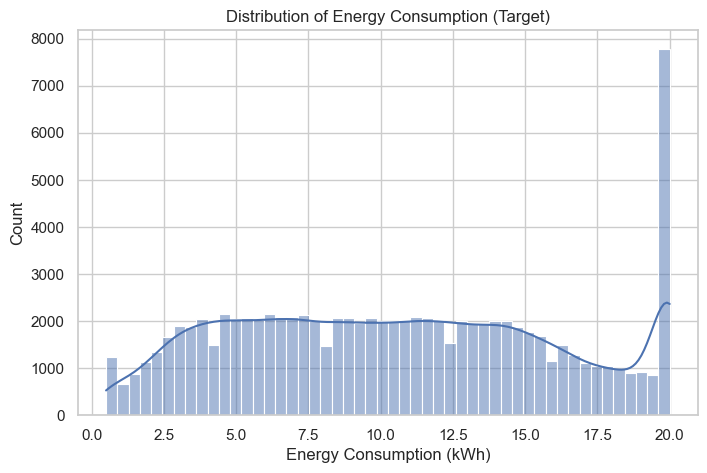

count    90000.000000
mean        10.571988
std          5.519494
min          0.500000
25%          6.000000
50%         10.400000
75%         14.800000
max         20.000000
Name: Energy_Consumption_kWh, dtype: float64


In [17]:
# Target Distribution
plt.figure(figsize=(8,5))
sns.histplot(final_train_df[target_col], kde=True)
plt.title("Distribution of Energy Consumption (Target)")
plt.xlabel("Energy Consumption (kWh)")
plt.show()

# Summary stats
print(final_train_df[target_col].describe())

**2. Numerical Feature Distributions**

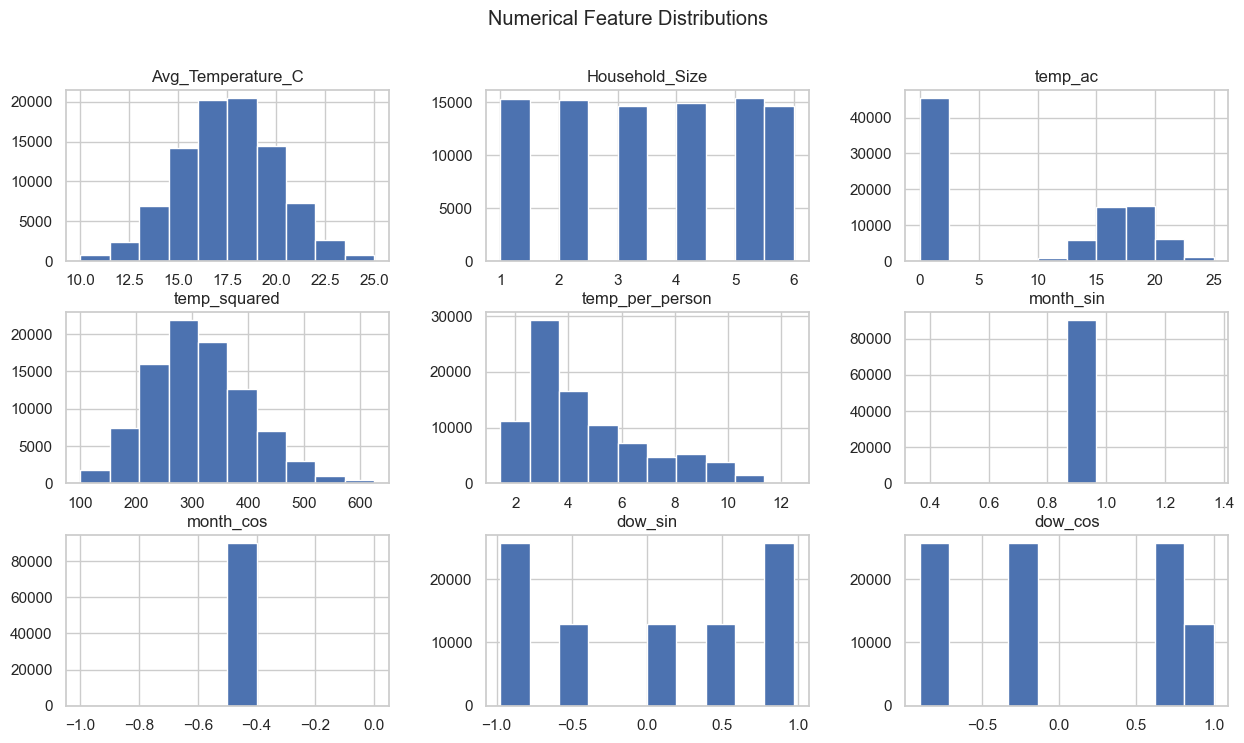

In [18]:
# Numerical feature distributions
num_cols = ["Avg_Temperature_C", "Household_Size"]
num_cols = [
    "Avg_Temperature_C",
    "Household_Size",
    "temp_ac",
    "temp_squared",
    "temp_per_person",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos"
]

final_train_df[num_cols].hist(figsize=(15,8))
plt.suptitle("Numerical Feature Distributions")
plt.show()

**3. Categorical Feature Analysis**

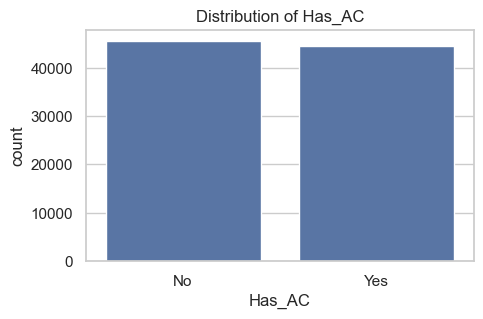

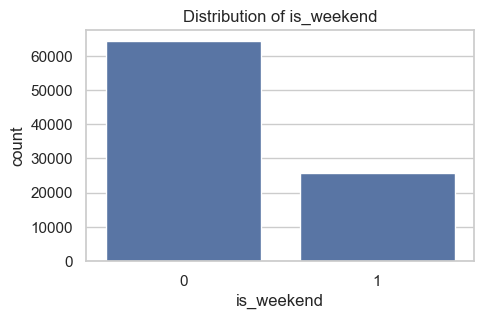

In [19]:
cat_cols = ["Has_AC", "is_weekend"]

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=final_train_df)
    plt.title(f"Distribution of {col}")
    plt.show()

**4. Correlation Analysis**

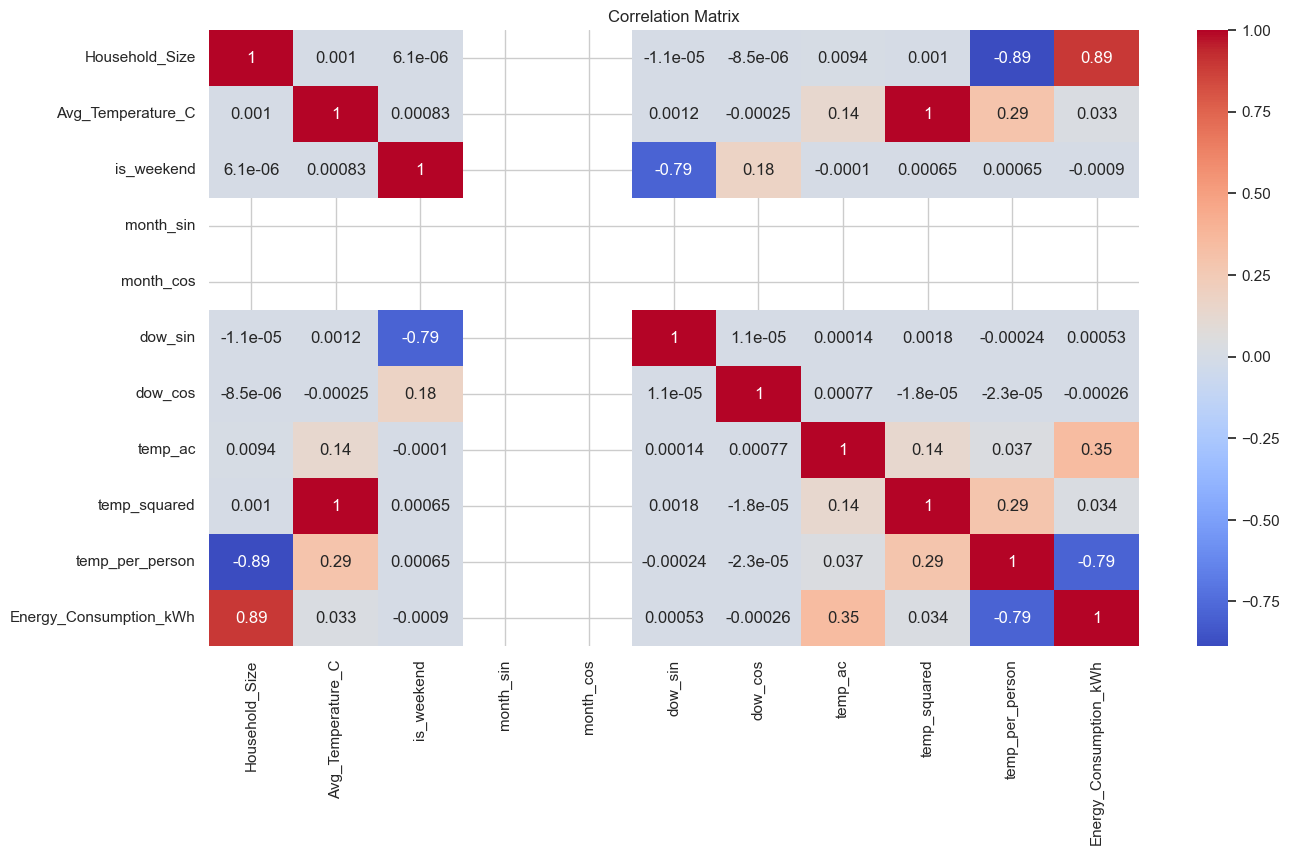

In [20]:
# correlation matrix
plt.figure(figsize=(15,8))
sns.heatmap(final_train_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**5. Feature vs Target Relationships**

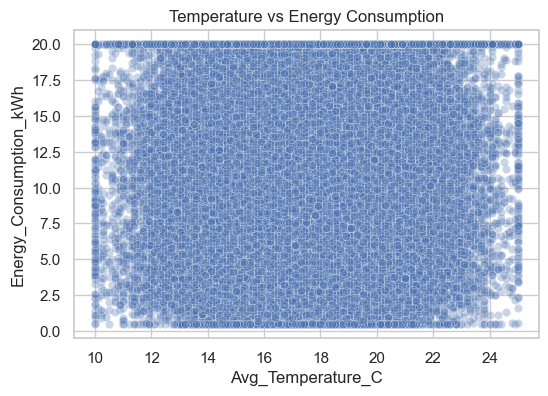

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Avg_Temperature_C",
    y=target_col,
    data=final_train_df,
    alpha=0.3
)
plt.title("Temperature vs Energy Consumption")
plt.show()

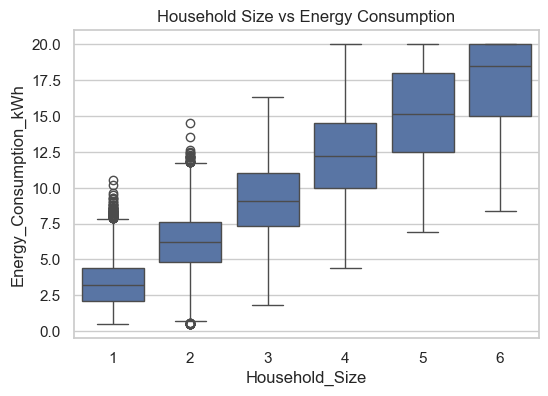

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Household_Size",
    y=target_col,
    data=final_train_df
)
plt.title("Household Size vs Energy Consumption")
plt.show()

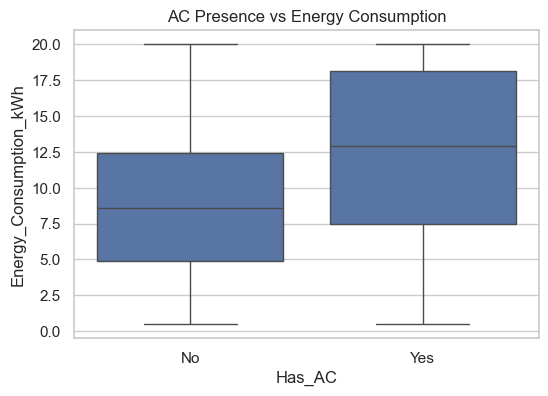

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Has_AC",
    y=target_col,
    data=final_train_df
)
plt.title("AC Presence vs Energy Consumption")
plt.show()

In [24]:
print("Missing values in train:\n", final_train_df.isnull().sum())
print("\nMissing values in test:\n", final_test_df.isnull().sum())

Missing values in train:
 Household_Size            0
Avg_Temperature_C         0
Has_AC                    0
is_weekend                0
month_sin                 0
month_cos                 0
dow_sin                   0
dow_cos                   0
temp_ac                   0
temp_squared              0
temp_per_person           0
Energy_Consumption_kWh    0
dtype: int64

Missing values in test:
 Household_Size        0
Avg_Temperature_C    37
Has_AC                0
is_weekend            0
month_sin             0
month_cos             0
dow_sin               0
dow_cos               0
temp_ac              37
temp_squared         37
temp_per_person      37
dtype: int64
